In [18]:
# Import libraries
import numpy as np
import pandas as pd
import torch
import torch.distributions as dist
from scipy.stats import gamma
from concurrent.futures import ProcessPoolExecutor
import functools
from sklearn.linear_model import Ridge
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

Sample from posterior

In [19]:
# FFBS sampler
def sample_trajectory(ES, VS, Cov):
    T = len(ES)
    S = np.zeros(T)

    S[T-1] = np.random.normal(ES[T-1], np.sqrt(VS[T-1]))

    for t in range(T-2, -1, -1):
        J = Cov[t+1] / VS[t+1]
        mean = ES[t] + J * (S[t+1] - ES[t+1])
        var  = VS[t] - J * Cov[t+1]
        var = max(var, 1e-8)

        S[t] = np.random.normal(mean, np.sqrt(var))

    return S

# helper functions to compute various quantities
def compute_empirical_growth(df_c):
    df_c = df_c.sort_values('date').copy()
    df_c['emp_growth'] = np.exp(df_c['log_cases'].diff())
    return df_c

def get_block_covariates(country, time_block, block_cov):
    key = (country, time_block)
    if key in block_cov.index:
        return (float(block_cov.loc[key, 'stringency_lag']),
                float(block_cov.loc[key, 'log_vac_lag']))
    return 0.0, 0.0

def compute_model_R(df_c, beta, theta_c, block_cov, sigma2=0.03):
    mu = []

    U_c1 = float(df_c['pc1'].iloc[0])
    U_c2 = float(df_c['pc2'].iloc[0])

    for _, row in df_c.iterrows():
        V_str, V_vac = get_block_covariates(row['country'], row['time_block'], block_cov)

        val = (beta[0]
               + beta[1]*U_c1
               + beta[2]*U_c2
               + beta[3]*V_str
               + beta[4]*V_vac
               + theta_c)

        # exponentiate
        if sigma2 is not None:
            val = np.exp(val + 0.5 * sigma2)  # corrected mean
        else:
            val = np.exp(val)

        mu.append(val)

    return np.array(mu)

# sampler for each coountry
def sample_posterior(results, countries, n_samples=100):
    all_samples = {}
    
    for country in countries:
        res = results[country]
        ES  = res['ES']
        ES2 = res['ES2']
        ESS = res['ESS']
        
        VS      = ES2 - ES**2
        Cov     = np.zeros_like(ES)
        Cov[1:] = ESS - ES[1:] * ES[:-1]
        
        samples = np.array([
            sample_trajectory(ES, VS, Cov)
            for _ in range(n_samples)
        ])  # shape (n_samples, T)
        
        all_samples[country] = {
            'S_samples' : samples, 
            'dates'     : res['dates'], 
        }
    
    return all_samples

# generate plot
def plot_growth(country, df, all_samples, beta, theta, block_cov, sigma2=0.03):
    df_c = df[df['country'] == country].copy()
    df_c = compute_empirical_growth(df_c)
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # load stored S samples and compute R
    S_samples = all_samples[country]['S_samples']
    R_samples = np.exp(np.diff(S_samples, axis=1)) 

    post_mean = R_samples.mean(axis=0)
    lower     = np.percentile(R_samples, 10, axis=0)
    upper     = np.percentile(R_samples, 90, axis=0)

    # empirical
    emp = df_c['emp_growth'].values[1:]

    # model-implied
    model_R = compute_model_R(df_c, beta, theta[country], block_cov)
    model_R = model_R[1:]

    dates_plot = df_c['date'].values[1:]

    # plot
    plt.figure(figsize=(12, 6))
    plt.fill_between(dates_plot, lower, upper,
                     color='gray', alpha=0.3, label='Posterior 10–90%')
    plt.plot(dates_plot, post_mean,
             color='black', lw=2, label='Posterior mean')
    plt.plot(dates_plot, emp,
             color='blue', lw=1.5, alpha=0.7, label='Empirical')
    plt.step(dates_plot, model_R, where='mid',
             color='red', lw=2, label='Model-implied')

    plt.title(f'Growth comparison: {country}')
    plt.ylabel('Growth factor')
    plt.xlabel('Date')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [20]:
if __name__ == '__main__':
    freq = "seasonal"  # TODO: change
    with open(f'../data/posterior_results_{freq}.pkl', 'rb') as f:
        data = pickle.load(f)

    results   = data['results']
    beta      = data['beta']
    theta     = data['theta']
    alpha     = data['alpha']
    tau2      = data['tau2']
    sigma2    = data['sigma2']
    countries = list(results.keys())

    # sample posterior trajectories
    all_samples = sample_posterior(results, countries, n_samples=1000)

 Posterior reproduction rate

In [21]:
# summarise R
records = []
for country in countries:
    S_samples = all_samples[country]['S_samples']         # (n_samples, T)
    R_samples = np.exp(np.diff(S_samples, axis=1))        # (n_samples, T-1)
    dates     = all_samples[country]['dates']

    R_mean = R_samples.mean(axis=0)
    R_low  = np.percentile(R_samples,  5, axis=0)
    R_high = np.percentile(R_samples, 95, axis=0)
    R_prob = (R_samples > 1).mean(axis=0)

    for t in range(R_samples.shape[1]):
        records.append({
            'country'  : country,
            'date'     : dates[t + 1],
            'R_mean'   : R_mean[t],
            'R_low'    : R_low[t],
            'R_high'   : R_high[t],
            'P_R_gt_1' : R_prob[t],
        })

df_out = pd.DataFrame(records)
df_out.to_csv(f'../data/R_posterior_summary_{freq}.csv', index=False)
print(f"Saved R_posterior_summary_{freq}.csv")

Saved R_posterior_summary_seasonal.csv


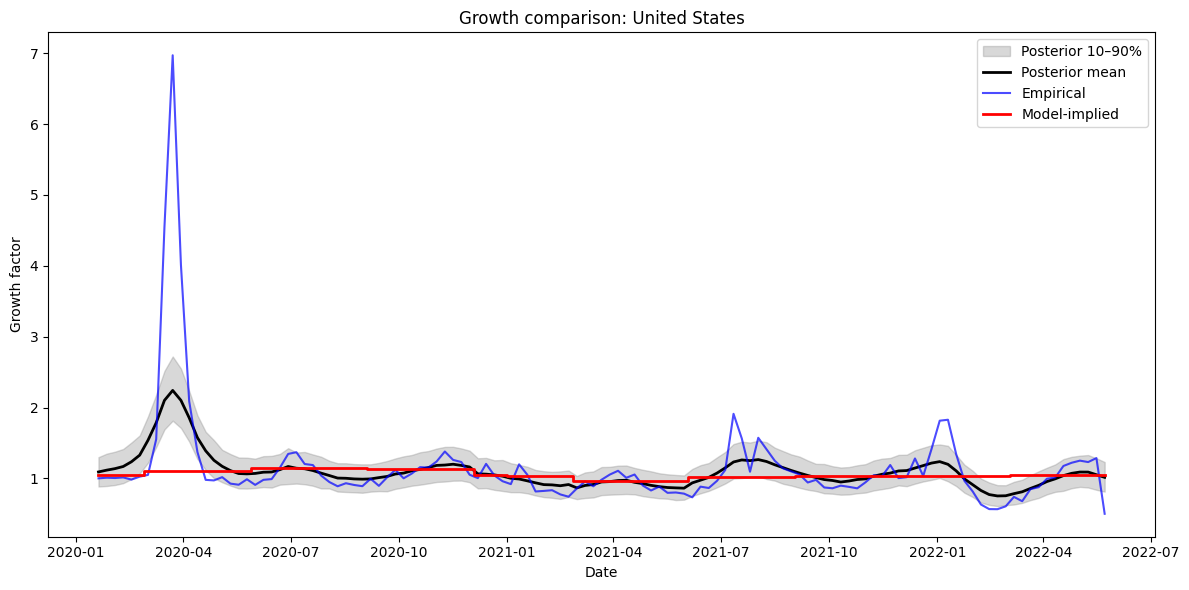

In [22]:
# Load data
df = pd.read_csv(f'../data/covid_{freq}.csv', parse_dates=['date'])
df = df.sort_values(['country', 'date']).reset_index(drop=True)
block_cov = pd.read_csv(f'../data/block_cov_{freq}.csv')
block_cov = block_cov.set_index(['country', 'time_block'])

# Load posterior
with open(f'../data/posterior_results_{freq}.pkl', 'rb') as f:
    saved = pickle.load(f)

plot_growth(
    country='United States',
    df=df,
    all_samples=all_samples,
    beta=beta,
    theta=theta,
    block_cov=block_cov,
    sigma2=sigma2,
)

Posterior predictive band

In [27]:
def posterior_predictive_band(country, df, all_samples, alpha, tau2):
    df_c = (
        df[df['country'] == country]
        .sort_values('date')
        .reset_index(drop=True)
    )

    Y     = df_c['log_cases'].values
    dates = pd.to_datetime(df_c['date'])

    S_samples = all_samples[country]['S_samples']
    n_samples, T = S_samples.shape

    # generate replicated observations
    Y_samples = (
        S_samples
        + alpha[country]
        + np.random.normal(0, np.sqrt(tau2), size=(n_samples, T))
    )

    pred_mean = Y_samples.mean(axis=0)
    lower     = np.quantile(Y_samples, 0.05, axis=0)
    upper     = np.quantile(Y_samples, 0.95, axis=0)

    plt.figure(figsize=(12, 5))
    plt.fill_between(dates, lower, upper,
                     color='steelblue', alpha=0.25,
                     label='90% posterior predictive interval')
    plt.plot(dates, pred_mean,
             color='steelblue', linewidth=2,
             label='Posterior predictive mean')
    plt.plot(dates, Y,
             color='black', linewidth=2,
             label='Observed')

    plt.title(f'Posterior Predictive Check ({country})')
    plt.xlabel('Date')
    plt.ylabel('Log reported cases')
    plt.legend()
    plt.show()

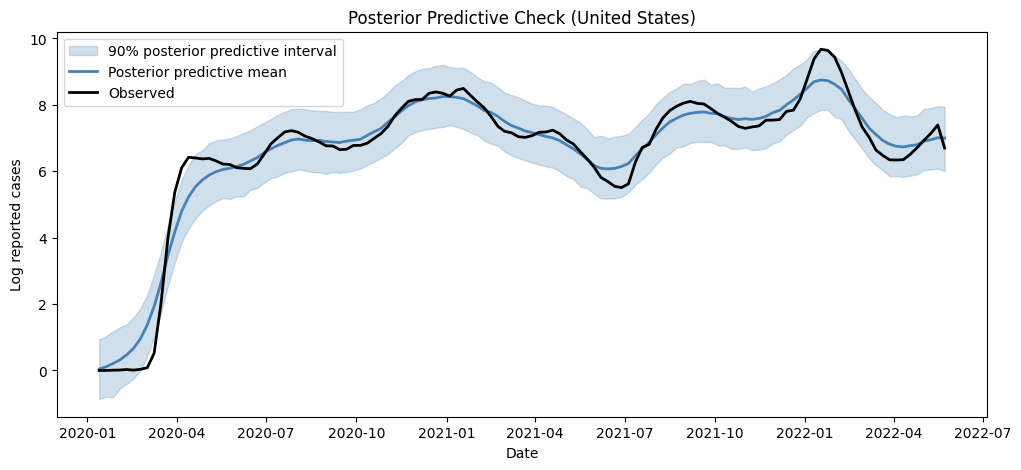

In [28]:
posterior_predictive_band(
    country='United States',
    df=df,
    all_samples=all_samples,
    alpha=alpha,
    tau2=tau2
)

- The mismatch near the beginning of the pandemic indicates that the first-order temporal dynamics may have difficulty capturing sudden transitions or delayed reporting effects.

- Most observed values lie within the posterior predictive band, suggesting that the model fits the overall scale and long-term trend of the data reasonably well.

- The posterior predictive band is relatively wide throughout much of the time period, indicating substantial uncertainty in the latent epidemic dynamics and reporting process.

- The model tends to underestimate the sharpness and magnitude of some outbreak peaks, particularly during early 2022.


Autocorrelation across residuals

In [29]:
def compute_residuals(country, df, results):
    df_c = df[df['country'] == country].sort_values('date').reset_index(drop=True)

    ES = results[country]['ES']  # posterior mean of Z_t
    assert len(ES) == len(df_c)
    residual = df_c['log_cases'].values - ES

    return df_c['date'].values, residual

def plot_residual_acf(country, df, results, nlags=10):
    dates, residual = compute_residuals(country, df, results)

    acf_vals = acf(residual, nlags=nlags)

    n = len(residual)
    ci = 1.96 / np.sqrt(n)

    plt.figure(figsize=(6,4))

    plt.stem(range(len(acf_vals)), acf_vals)   # ← fixed line

    plt.axhline(0, color='black')
    plt.axhline(ci, linestyle='--', color='red')
    plt.axhline(-ci, linestyle='--', color='red')

    plt.title(f'Residual ACF ({country})')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.show()

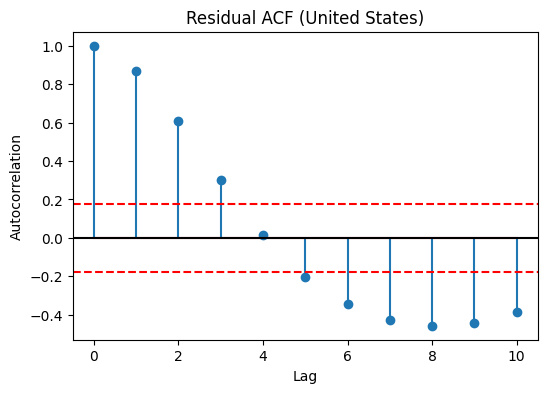

In [30]:
plot_residual_acf(
    country='United States',
    df=df,
    results=results,
    nlags=10
)

- The residual ACF exhibits strong positive autocorrelation at short lags, indicating remaining temporal dependence not captured by the model.

Forecasting evaluation

In [31]:
def sample_forecast(S_t, mu_future, alpha_c, tau2, sigma2, max_horizon):
    S_prev  = S_t
    Y_draws = np.empty(max_horizon)

    for h in range(max_horizon):
        S_next     = S_prev + mu_future[h] + np.random.normal(0, np.sqrt(sigma2))
        Y_draws[h] = S_next + alpha_c      + np.random.normal(0, np.sqrt(tau2))
        S_prev     = S_next

    return Y_draws

def plot_forecast_fan(country, df, results, alpha, tau2, horizon=1,
                      sigma2=0.03, n_train_frac=0.75, n_samples=300, ax=None):
    df_c = (
        df[df['country'] == country]
        .sort_values('date')
        .reset_index(drop=True)
    )
    Y      = df_c['log_cases'].values.astype(float)
    dates  = df_c['date'].values
    T      = len(Y)

    res    = results[country]
    ES     = res['ES']
    VS     = res['ES2'] - res['ES'] ** 2
    Cov    = np.zeros_like(ES)
    Cov[1:] = res['ESS'] - ES[1:] * ES[:-1]
    mu_seq = res['mu_seq']

    alpha_c = alpha[country]
    t_start = int(np.floor(n_train_frac * T))
    records = []

    for t in range(t_start, T - 1):
        S_at_t = np.array([
            sample_trajectory(ES[:t + 1], VS[:t + 1], Cov[:t + 1])[t]
            for _ in range(n_samples)
        ])

        mu_future = np.array([
            mu_seq[t + h] if (t + h) < T else 0.0
            for h in range(1, horizon + 1)
        ])

        Y_pred = np.stack([
            sample_forecast(S_at_t[m], mu_future, alpha_c, tau2, sigma2, horizon)
            for m in range(n_samples)
        ])

        t_target = t + horizon
        if t_target >= T:
            continue

        samples = Y_pred[:, horizon - 1]
        q05, q10, q90, q95 = np.percentile(samples, [5, 10, 90, 95])

        records.append({
            'date_target': dates[t_target],
            'pred_mean'  : samples.mean(),
            'q05': q05, 'q10': q10, 'q90': q90, 'q95': q95,
        })

    sub = pd.DataFrame(records).sort_values('date_target')

    # ── axes handling ─────────────────────────────────────────────────────────
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(dates, Y, color='black', lw=1.5, alpha=0.6, label='Observed')
    ax.plot(sub['date_target'], sub['pred_mean'], color='blue', lw=1.5,
            label=f'{horizon}-wk-ahead mean')
    ax.fill_between(sub['date_target'], sub['q10'], sub['q90'],
                    color='blue', alpha=0.18, label='80% PI')
    ax.fill_between(sub['date_target'], sub['q05'], sub['q95'],
                    color='blue', alpha=0.09, label='95% PI')
    ax.set_title(f'{country} — {horizon}-week-ahead predictive intervals')
    ax.set_xlabel('Date')
    ax.set_ylabel('Log-cases per million')
    ax.legend()

    if standalone:
        plt.tight_layout()
        plt.show()


--- Horizon: 1 ---


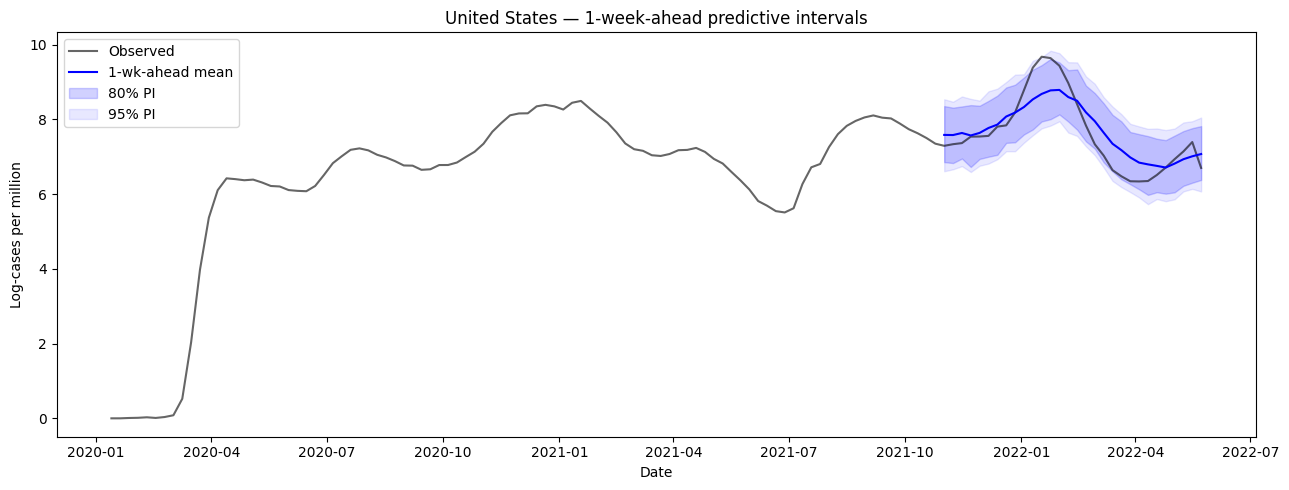


--- Horizon: 2 ---


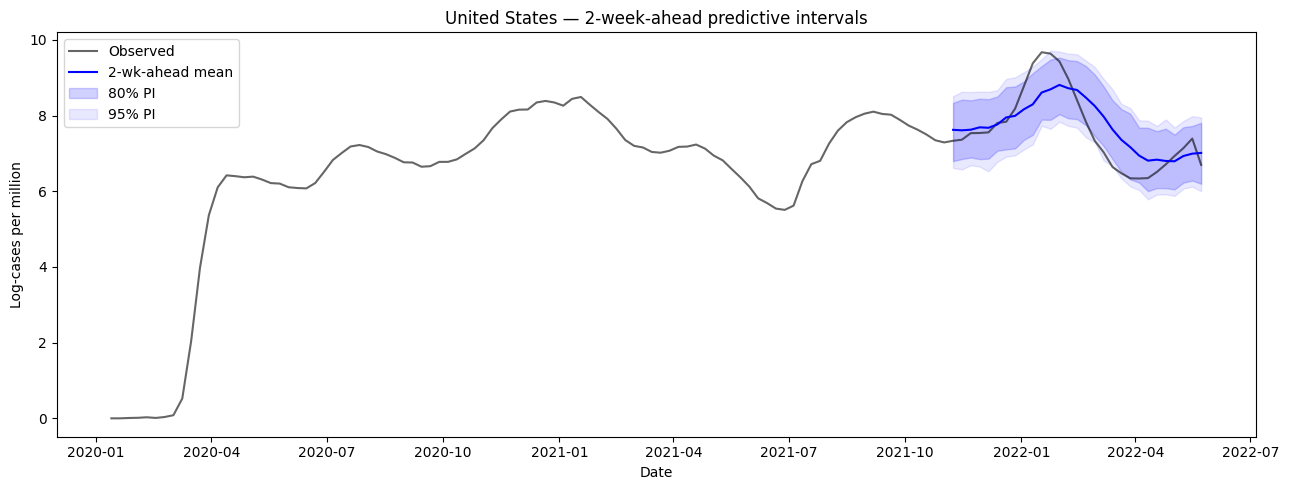


--- Horizon: 4 ---


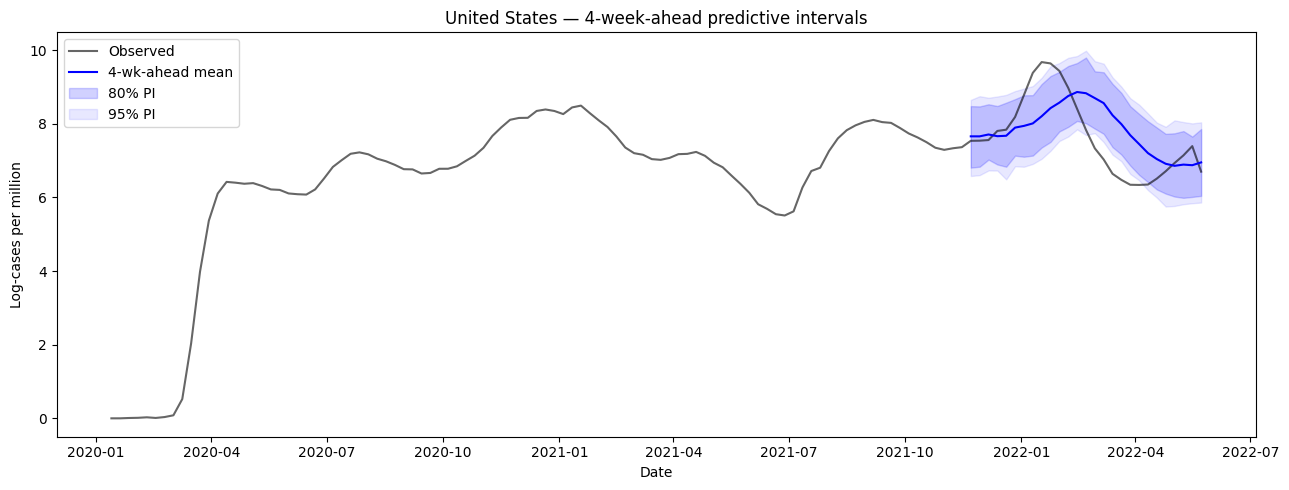


--- Horizon: 8 ---


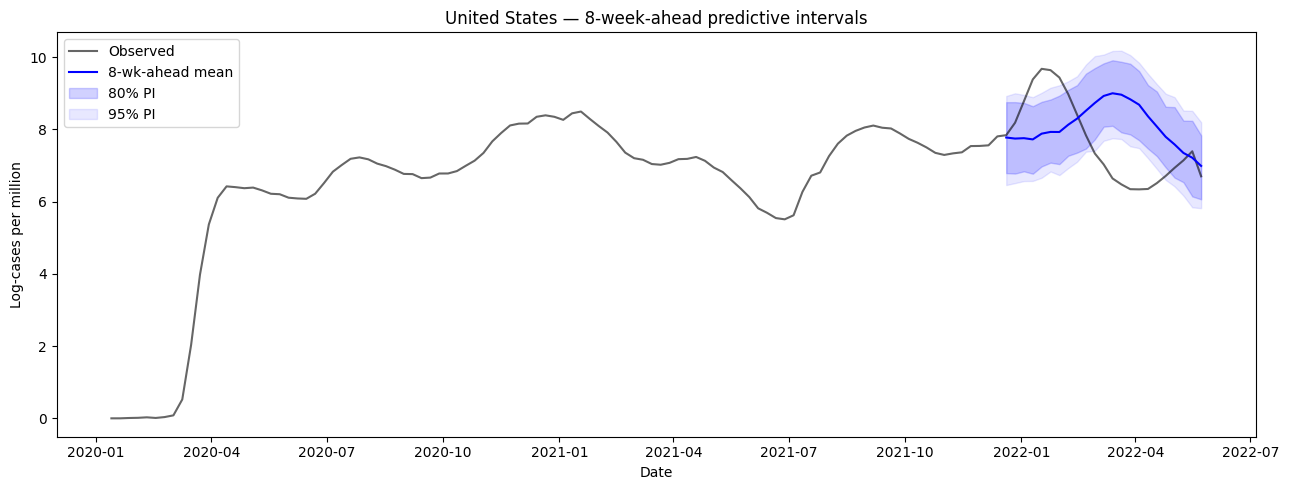

In [32]:
freq = 'seasonal'

df = pd.read_csv(f'../data/covid_{freq}.csv', parse_dates=['date'])
df = df.sort_values(['country', 'date']).reset_index(drop=True)

with open(f'../data/posterior_results_{freq}.pkl', 'rb') as f:
    saved = pickle.load(f)

COUNTRY  = 'United States'
HORIZONS = [1, 2, 4, 8]   # compare across different horizons

for horizon in HORIZONS:
    print(f"\n--- Horizon: {horizon} ---")
    plot_forecast_fan(
        country      = COUNTRY,
        df           = df,
        results      = results,
        alpha        = alpha,
        tau2         = tau2,
        horizon      = horizon,
        sigma2       = 0.03,
        n_train_frac = 0.75,
        n_samples    = 300,
    )

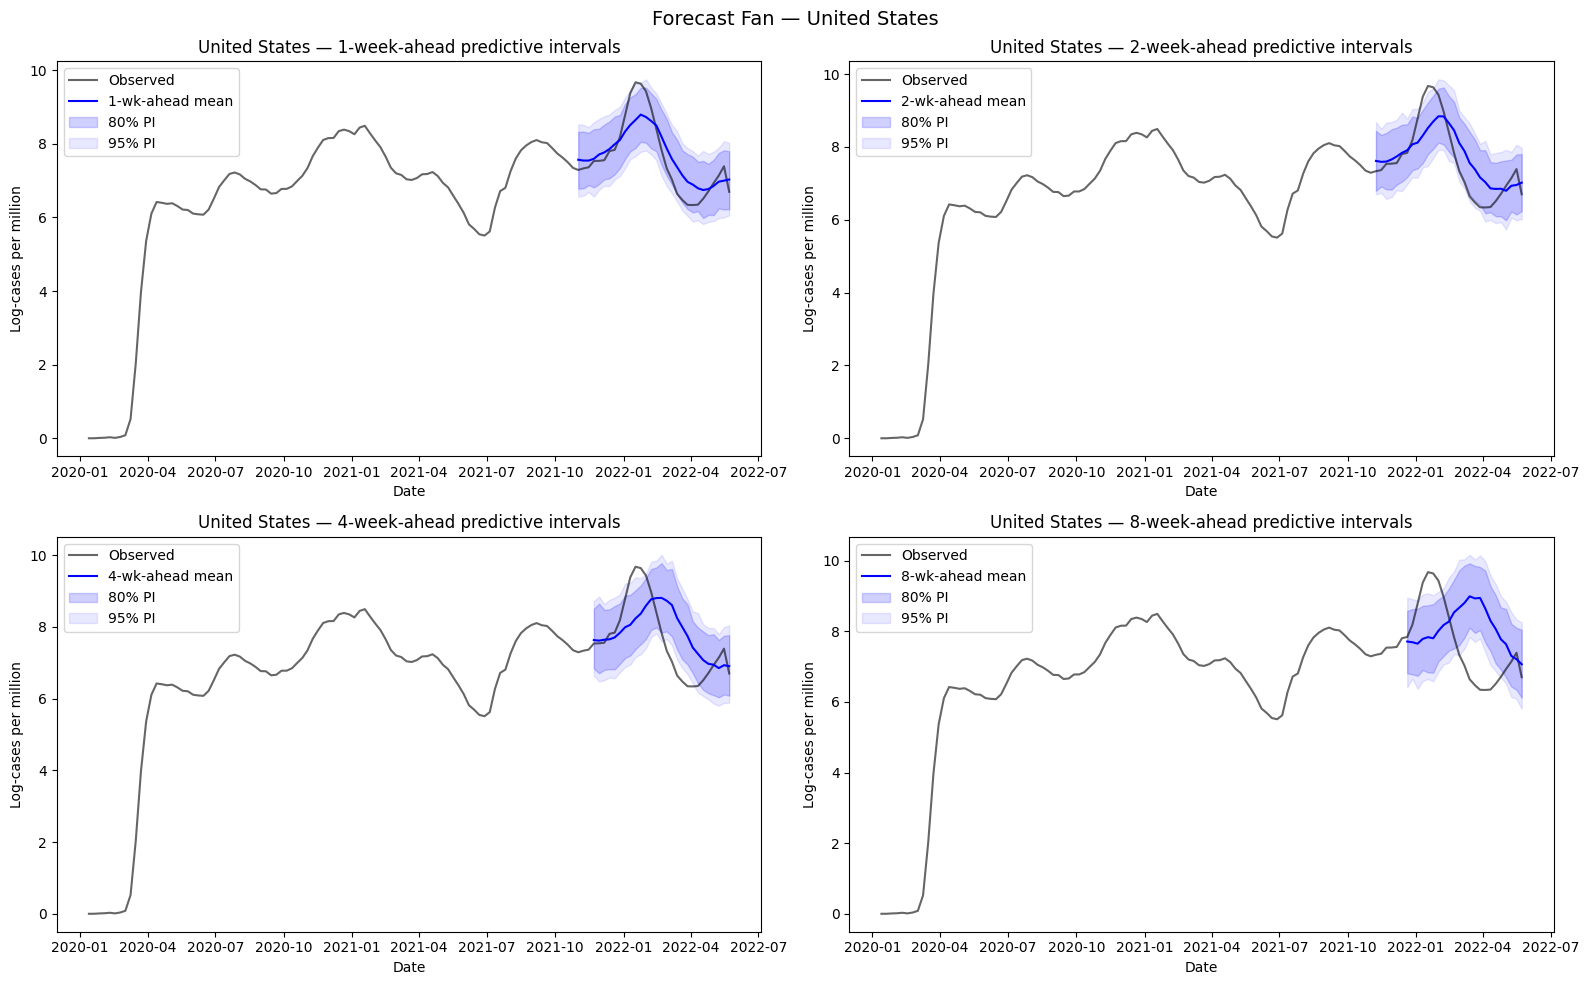

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, horizon in zip(axes.flatten(), HORIZONS):
    plot_forecast_fan(
        country      = COUNTRY,
        df           = df,
        results      = results,
        alpha        = alpha,
        tau2         = tau2,
        horizon      = horizon,
        sigma2       = 0.03,
        n_train_frac = 0.75,
        n_samples    = 300,
        ax           = ax,
    )

fig.suptitle(f'Forecast Fan — {COUNTRY}', fontsize=14)
plt.tight_layout()
plt.show()

- The model produces reasonably calibrated short-term forecasts, with most observed values remaining within the predictive intervals across all forecast horizons.

- Predictive uncertainty increases as the forecast horizon grows, reflected by the widening predictive intervals from 1-week to 8-week-ahead forecasts.

- These results suggest that the current first-order latent dynamics capture short-term persistence reasonably well but may be insufficient for modeling more complex multi-scale temporal behavior.
